<h1><center>Modelling and Engineering of Nanoscale Materials <br> Exercises session 7: Levels of theory - 2025 </center></h1>
<center>massimo.bocus@ugent.be,  arnout.maet@ugent.be, thomas.nicholas@ugent.be</center>

In [1]:
%matplotlib inline
import os, numpy as np, h5py, matplotlib.pyplot as plt

from pyiron import Project, ase_to_pyiron
from ase.io import read

from ase.units import *

<div class="alert alert-block alert-warning">
<b>Educational Objectives</b> <br> 
    
(1)  Understand the difference between the different Hartree Fock flavors (UHF,RHF,ROHF) <br>
(2)  Visualize the HF limit, its impact on an energy diagram, and the contrast with DFT <br>
(3)  Understand the difference between HF and Kohn-Sham orbital energies <br>
(4)  Discover the vastness of the functional zoo for DFT and recognize the difference in accuracy in correspondence with Jacob's ladder<br>
(5)  Learn about the problem with long-range interactions in DFT and utilize possible solutions, *e.g.* empirical dispersion schemes 
</div>

## Introduction

In this exercise lesson, we will only use Gaussian job types to learn about the different levels of theory and their effect on the system's properties. 

In [2]:
# Setting up project
pr = Project('session7')

## Exercise 1: The different flavors of HF

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Determine the ground state of an oxygen atom with Hartree-Fock <br>
</div>

Consider an isolated oxygen atom. Draw the electronic structure configuration of this atom in its ground state, and calculate the most favorable HF-based energy using a 6-31+G(d) basis set. Looking at __[the Gaussian site:HF](https://gaussian.com/hf/)__ might be informative.

<div class="alert alert-block alert-success">
<b>Answer the following questions using the code below:</b> <br>   
<ol type='a'>
<li> What is the difference between HF, RHF, UHF and ROHF?</li>
<br>
<li> Which of these methods provides the lowest energy and why? </li>
</ol>
</div>

In [70]:
ex1 = pr.create_group('ex1')

In [71]:
from ase.data.pubchem import pubchem_atoms_search
O_atom = ex1.create.structure.atoms("O")

In [72]:
O_atom.plot3d()

NGLWidget()

In [7]:
def g16_job(pr, name, jobtype, structure, lot, basis_set, charge=0, multiplicity=1, settings={}, cluster='donphan', cores=4, run_time=5*60):
    job = pr.create_job(pr.job_type.Gaussian, name, delete_existing_job=True)
    
    ### Add the necessary variables to complete the definition of your job!
    # Assign the input parameters. Keep in mind that the level of theory and basis set should remain the same.
    job.structure = structure
    job.input['jobtype'] = jobtype
    job.input['lot'] =  lot
    job.input['basis_set'] = basis_set
    job.input['settings'] = settings

    # set charge and multiplicity
    job.input['charge'] = charge
    job.input['spin_mult'] = multiplicity
    
    # Select a cluster and provide the nprocs and walltime for the job
    job.server.queue = cluster
    job.server.cores = cores 
    job.server.run_time = run_time
    
    # Execute the job 
    job.run()
    return job

In [8]:
job_opt_HF = g16_job(ex1, "is_O_opt_HF", "sp", O_atom, "HF", "6-31+G(d)")

The job is_O_opt_HF was saved and received the ID: 1634
Queue system id:  202589304


### Use the levels of theory for the two diffent spin multiplicities

In [20]:
multiplicity_used = [1, 3]
lot_used = ["HF", "RHF", "ROHF", "UHF"]

In [10]:
# run jobs
for multiplicity in multiplicity_used:
    for lot in lot_used:
        name = "is_sp_%s_%s" % (lot, multiplicity)
        job = g16_job(ex1, name, "sp", O_atom, lot, "6-31+G(d)", multiplicity = multiplicity, cores=1)

The job is_sp_HF_1 was saved and received the ID: 1635
Queue system id:  202589314
The job is_sp_RHF_1 was saved and received the ID: 1636
Queue system id:  202589324
The job is_sp_UHF_1 was saved and received the ID: 1637
Queue system id:  202589334
The job is_sp_ROHF_1 was saved and received the ID: 1638
Queue system id:  202589344
The job is_sp_HF_3 was saved and received the ID: 1639
Queue system id:  202589354
The job is_sp_RHF_3 was saved and received the ID: 1640
Queue system id:  202589364
The job is_sp_UHF_3 was saved and received the ID: 1641
Queue system id:  202589374
The job is_sp_ROHF_3 was saved and received the ID: 1642
Queue system id:  202589384


In [73]:
for lot in lot_used:
    energies_mult= []
    for multiplicity in multiplicity_used:
        name = "is_sp_%s_%s" % (lot, multiplicity)
        job = ex1.load(name)
        energies = job.output.energy_tot
        if energies is not None:
            energy_eV = energies[-1]
            energy_Ha = energy_eV * 0.0367492929
            energies_mult.append(energy_Ha)
        else: 
            energies_mult.append(0.0)
    print("%s : %.6f  %.6f" % (lot, energies_mult[0], energies_mult[1]))


2026-01-02 15:50:31,711 - pyiron_log - WARNING - Could not access energy_tot, returning None!


HF : -74.660153  -74.786704
RHF : -74.660153  0.000000
ROHF : -74.660153  -74.781390
UHF : -74.660153  -74.786704


### Note:
RHF fails for multiplicity 3
because it is meant to treat all orbitals as if they are filled with 2 electrons. For S=1 (Multiplicity three) this of course not the case (Figure 1 solutions).

## Exercise 2: HF vs post-HF

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Reproduce the energy diagram from the helium case study in the theory session. <br>
    2. Understand the difference in the limitations between (post-)HF and DFT methods on an energy diagram.
</div>

Consider an isolated He atom, and calculate its energy using a variety of (post-)HF and DFT methods, to construct an energy diagram similar to the one illustrated during the theory sessions, using the same levels of theory and basis set (week 5 - slide 83, ignore the Dyson calculations). 

<div class="alert alert-block alert-success">
<b>Answer the following questions using the code below:</b> <br>   
<ol type='a'>
<li> Which of these methods provides the lowest energy? Is this method guaranteed to find the most accurate energy in the limit of an infinite basis set?</li>
<br>
<li> Which method provides the most accurate energy (compare to -2.90338583(13) Ha, taken from NIST) </li>
<br>
<li> How large is the electron correlation energy? </li>
</ol>
</div>

In [74]:
ex2 = pr.create_group('ex2')

In [75]:
He_atom = ex1.create.structure.atoms("He")

In [76]:
lots = ["HF", "MP2", "MP3", "MP4", "CI", "BLYP", "B3LYP"]

In [39]:
for lot in lots:
    name = "He_%s" % (lot)
    job = g16_job(ex2, name, "sp", He_atom, lot, "6-311G(d,p)", cores=1)

The job He_HF was saved and received the ID: 114
Queue system id:  202226994
The job He_MP2 was saved and received the ID: 115
Queue system id:  202227014
The job He_MP3 was saved and received the ID: 116
Queue system id:  202227024
The job He_MP4 was saved and received the ID: 117
Queue system id:  202227044
The job He_CI was saved and received the ID: 118
Queue system id:  202227084
The job He_BLYP was saved and received the ID: 119
Queue system id:  202227124
The job He_B3LYP was saved and received the ID: 120
Queue system id:  202227154


In [77]:
ex2.job_table()

,id,status,chemicalformula,job,subjob,projectpath,project,timestart,timestop,totalcputime,computer,hamilton,hamversion,parentid,masterid
0,114,finished,He,He_HF,/He_HF,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex2/,2025-11-05 13:40:52.613475,2025-11-05 13:40:57.368212,4.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
1,115,finished,He,He_MP2,/He_MP2,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex2/,2025-11-05 13:41:09.564979,2025-11-05 13:41:14.853170,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
2,116,finished,He,He_MP3,/He_MP3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex2/,2025-11-05 13:41:26.614004,2025-11-05 13:41:31.960513,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
3,117,finished,He,He_MP4,/He_MP4,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex2/,2025-11-05 13:41:37.638252,2025-11-05 13:41:42.953340,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
4,118,finished,He,He_CI,/He_CI,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex2/,2025-11-05 13:41:56.255090,2025-11-05 13:42:01.344099,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
5,119,finished,He,He_BLYP,/He_BLYP,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex2/,2025-11-05 13:42:11.727342,2025-11-05 13:42:16.865896,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
6,120,finished,He,He_B3LYP,/He_B3LYP,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex2/,2025-11-05 13:42:24.281285,2025-11-05 13:42:29.123312,4.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None


In [78]:
dict_energies = {}
for lot in lots:
    name = "He_%s" % (lot)
    job = ex2.load(name)
    energy_Ha = job.output.energy_tot[-1] * 0.0367492929
    dict_energies[lot] = energy_Ha

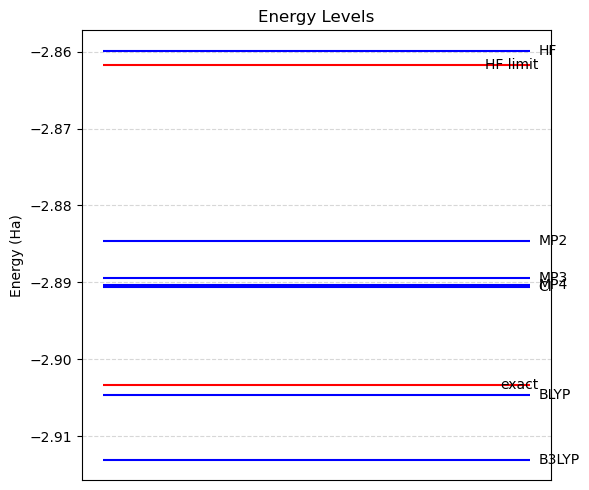

In [79]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
# Plot horizontal lines
for i, (method, energy) in enumerate(dict_energies.items()):
    plt.hlines(y=energy, xmin=0, xmax=1, color='blue')  # horizontal line across x=0..1
    plt.text(1.02, energy, method, va='center', ha='left')  # label to the right
true_energy = -2.90338583
plt.hlines(y=[true_energy], xmin=0, xmax=1, color='red')
plt.text(1.02, true_energy, "exact", va='center', ha='right')
HF_limit = -2.86168
plt.hlines(y=[HF_limit], xmin=0, xmax=1, color='red')
plt.text(1.02, HF_limit, "HF limit", va='center', ha='right')


plt.ylabel("Energy (Ha)")
plt.xticks([])  # hide x-axis
plt.title("Energy Levels")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [80]:
E_corr = dict_energies["HF"] - true_energy
print("%.3g Ha" % E_corr)

0.0435 Ha


## Exercise 3: Ionization potential and electron affinity of an oxygen atom

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Notice the difference between the HF and the Kohn-Sham orbital energies <br>
    2. Calculate the ionization potential and electron affinity 
</div>

Calculate the ionization potential (IP) and the electron affinity (EA) for an oxygen atom using the 6-31+G(d) with both HF and a DFT functional (*e.g.* B3LYP). Use Koopman's theorem at first to estimate these quantities.

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Is there a large difference between the IP and EA for HF and DFT? Why (not)? </li>
<br>
<li> What contribution is missing from the IP and EA when using Koopman's theorem? Calculate the influence of neglecting this contribution. </li>
</ol>
</div>

<div class="alert alert-block alert-info">
<b>Tip - the orbital energies </b> <br>

The energies of the alpha and beta orbitals are conveniently stored in your simulation output under `job['output/structure/dft/alpha_orbital_e']` and `job['output/structure/dft/beta_orbital_e']`, respectively.

</div>

In [81]:
ex3 = pr.create_group('ex3')

In [53]:
lots = ["HF", "B3LYP"]
basis_set = "6-31+G(d)"
multiplicity = 3 # most stable configuration for 0 (see exercise 1)
# do single point for neutral oxygen, its cation and anion. Spin multiplicities can be determined by draw the energy levels
# as in figure 1 of the solutions.
for lot in lots:
    name = "O_sp_%s" % (lot)
    job_ground = g16_job(ex3, name, "sp", O_atom, lot, basis_set, charge=0, multiplicity = multiplicity, cores=1)
    job_cation = g16_job(ex3, name + "_cation", "sp", O_atom, lot, basis_set, charge=+1, multiplicity = 4, cores=1)
    job_anion = g16_job(ex3, name + "_anion", "sp", O_atom, lot, basis_set, charge=-1, multiplicity = 2, cores=1)

The job O_sp_HF was saved and received the ID: 1643
Queue system id:  202589514
The job O_sp_HF_cation was saved and received the ID: 1644
Queue system id:  202589524
The job O_sp_HF_anion was saved and received the ID: 1645
Queue system id:  202589534
The job O_sp_B3LYP was saved and received the ID: 1646
Queue system id:  202589544
The job O_sp_B3LYP_cation was saved and received the ID: 1647
Queue system id:  202589554
The job O_sp_B3LYP_anion was saved and received the ID: 1648
Queue system id:  202589564


In [54]:
ex3.job_table()

,id,status,chemicalformula,job,subjob,projectpath,project,timestart,timestop,totalcputime,computer,hamilton,hamversion,parentid,masterid
0,123,finished,O,is_sp_RHF_1,/is_sp_RHF_1,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex3/,2025-11-05 14:10:18.212070,2025-11-05 14:10:23.929748,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
1,124,aborted,O,is_sp_RHF_3,/is_sp_RHF_3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex3/,2025-11-05 14:10:36.116616,2025-11-05 14:10:42.306205,6.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
2,125,finished,O,is_sp_UHF_1,/is_sp_UHF_1,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex3/,2025-11-05 14:10:50.751801,2025-11-05 14:10:56.152642,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
3,126,finished,O,is_sp_UHF_3,/is_sp_UHF_3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex3/,2025-11-05 14:11:05.778692,2025-11-05 14:11:10.946370,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
4,127,finished,O,is_sp_ROHF_1,/is_sp_ROHF_1,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex3/,2025-11-05 14:11:22.556752,2025-11-05 14:11:28.662946,6.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
5,128,finished,O,is_sp_ROHF_3,/is_sp_ROHF_3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex3/,2025-11-05 14:11:39.415375,2025-11-05 14:11:44.604875,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
6,137,finished,O,is_sp_HF_1,/is_sp_HF_1,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex3/,2025-11-05 15:03:06.571570,2025-11-05 15:03:12.766707,6.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
7,138,finished,O,is_sp_HF_3,/is_sp_HF_3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex3/,2025-11-05 15:03:24.239147,2025-11-05 15:03:30.380068,6.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
8,139,finished,O,is_sp_B3LYP_1,/is_sp_B3LYP_1,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex3/,2025-11-05 15:03:28.611322,2025-11-05 15:03:33.672583,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None
9,140,finished,O,is_sp_B3LYP_3,/is_sp_B3LYP_3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex3/,2025-11-05 15:03:43.980009,2025-11-05 15:03:49.309017,5.0,pyiron@node4014.donphan.os#1#donphan,Gaussian,0.1,None,None


#### Code from the solutions

In [82]:
def get_ip(job):
    if job.input['spin_mult'] == 1: # no unpaired electrons
        orbital_energies = np.sort(np.hstack((
        job['output/structure/dft/alpha_orbital_e'],
        job['output/structure/dft/alpha_orbital_e']
        )))
    else:
        orbital_energies = np.sort(np.hstack((
        job['output/structure/dft/alpha_orbital_e'],
        job['output/structure/dft/beta_orbital_e']
        )))

    # index = number of electrons - 1 (HOMO)
    n = int(job['output/structure/dft/n_electrons']-1)
    # orbital energies are stored in Ha (not electronvolt)
    return -orbital_energies[n]*Ha/(kJ/mol)
    
def get_ea(job):
    if job.input['spin_mult'] == 1: # no unpaired electrons
        orbital_energies = np.sort(np.hstack((
        job['output/structure/dft/alpha_orbital_e'],
        job['output/structure/dft/alpha_orbital_e']
        )))
    else:
        orbital_energies = np.sort(np.hstack((
        job['output/structure/dft/alpha_orbital_e'],
        job['output/structure/dft/beta_orbital_e']
        )))
    # index = number of alpha electrons (LUMO)
    n = int(job['output/structure/dft/n_electrons'])
    # orbital energies are stored in Ha (not electronvolt)
    return orbital_energies[n]*Ha/(kJ/mol)

In [83]:
lots = ["HF", "B3LYP"]
basis_set = "6-31+G(d)"
for lot in lots:
    # extract the jobs
    name = "O_sp_%s" % (lot) # spin multiplicty 3
    job_ground = ex3.load(name)
    job_cation = ex3.load(name + "_cation")
    job_anion = ex3.load(name + "_anion")
    
    # determine ionisation potential and electron affinity from the ground orbitals
    # using Koopman's theorem
    ip_koopman = get_ip(job_ground)
    ea_koopman = get_ea(job_ground)

    # get the exact IP and EA (in kJ/mol
    IP = (job_cation.output.energy_tot[-1] - job_ground.output.energy_tot[-1])*eV/(kJ/mol)
    EA = (job_anion.output.energy_tot[-1] - job_ground.output.energy_tot[-1])*eV/(kJ/mol)
    print("%s %.1f %.1f %.1f %.1f" % (lot, ip_koopman, IP, ea_koopman, EA))

/tmp/ipykernel_2236518/3196977796.py:9: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  job['output/structure/dft/alpha_orbital_e'],
/tmp/ipykernel_2236518/3196977796.py:10: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  job['output/structure/dft/beta_orbital_e']
/tmp/ipykernel_2236518/3196977796.py:14: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  n = int(job['output/structure/dft/n_electrons']-1)
/tmp/ipykernel_2236518/3196977796.py:26: DeprecationWarning: pyiron_base.

HF 1362.9 1161.4 187.2 52.9
B3LYP 889.7 1365.5 -501.4 -156.5


## Exercise 4: Trip to the functional zoo using trans-glyoxal

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Acquire a trans-glyoxal molecule <br>
    2. Perform a benchmark study on the structural properties of your molecule by passing through the rungs of Jacob's ladder using different functionals
</div>

In this exercise, we will compare the performance of several functionals for the structural parameters of a small organic molecule, namely trans-glyoxal. In a recent study by Brémond *et al.*, the performance of 59 functionals was evaluated for 47 molecules, containing trans-glyoxal as part of the CCse21 test set. Search for the structure of trans-glyoxal using the `pubchem_atoms_conformer_search` function. Then, using the 6-311+G(d,p) basis set and the `opt=tight` jobtype, perform a benchmark study by considering several functionals. Below is a list of functional types you could consider and an example, feel free to add some yourself. To find the correct name of the functional within Gaussian please check __[the Gaussian site:DFT](https://gaussian.com/dft/)__ and __[the Gaussian site:MP](https://gaussian.com/mp/)__!

* Hartree-Fock and a post-Hartree-Fock method (*e.g.* MP2) 
* A parameter-free GGA (*e.g.* PBE)
* A parameter-free meta-GGA (*e.g.* TPSS)
* A hybrid method with exact HF exchange: (*e.g.* B3LYP). How much HF exchange does this functional include? Find this in the log-file of your Gaussian calculation. 
* A double hybrid method with exact Hartree-Fock (HF) exchange combined with an MP2-like correlation: *e.g.* B2PLYP.
* A Grimme dispersion-corrected GGA functional (*e.g.* PBE+D3). How does the correction influence the structure w.r.t. the pure form? Does it become better or not? Note that this empirical correction requires an extra keyword, use the settings input for this!

<div class="alert alert-block alert-info">
<b>Remember - log files</b> <br>
    
Just like a `Yaff` job, the `Gaussian` job also has the `log()` function to show its output log file.

```python
job.log()
```

</div>

<div class="alert alert-block alert-info">
<b>Tip - verbosity</b> <br>
    
To get more output from a Gaussian job (in the log file), you have to put the verbosity on `high`.

```python
job.input['verbosity'] = 'high'
```

</div>

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Compare your calculated bond lengths (and bending angles) with the reference structure of Piccardo et al. <a href="https://doi.org/10.1021/jp511432m">(here)</a> and the benchmark study of Brémond et al. (look in the Supporting Information <a href="https://doi.org/10.1021/acs.jctc.5b01144">here</a>) obtained with the same functional. </li>
<br>
<li> Take a particular look at (Figure 1 and) Figure 2 in the benchmark study <a href="https://doi.org/10.1021/acs.jctc.5b01144">(here)</a>. Do you obtain the same trend? If not, can you explain this? How transferable are your conclusions?</li>
<br>
<li> Do these results agree with Jacob's ladder?</li>
</ol>
</div>

In [98]:
ex4 = pr.create_group('ex4')

In [99]:
# Add code here
from ase.data.pubchem import pubchem_atoms_conformer_search
glyoxal = ase_to_pyiron(pubchem_atoms_conformer_search(name="glyoxal")[0])
glyoxal.plot3d(spacefill=False)

NGLWidget()

In [100]:
basis_set = "6-311+G(d,p)"
lots= ["HF", "MP2", "B3LYP", "B2LYP", "PBE PBE", "TPSS TPSS"]

In [17]:
for lot in lots:
    name_job = "opt_test_" + lot
    job = g16_job(ex4, name_job, "opt=tight", glyoxal, lot, basis_set, settings={}, cluster='shinx', cores=4, run_time=10*60)

The job opt_test_HF was saved and received the ID: 674
Queue system id:  283650750
The job opt_test_MP2 was saved and received the ID: 675
Queue system id:  283650760
The job opt_test_PBE was saved and received the ID: 676
Queue system id:  283650770
The job opt_test_TPSS was saved and received the ID: 677
Queue system id:  283650780
The job opt_test_B3LYP was saved and received the ID: 678
Queue system id:  283650790
The job opt_test_B2LYP was saved and received the ID: 679
Queue system id:  283650800


In [25]:
lots_special = [ ]
for i, lot in enumerate(lots_special):
    name_job = "opt_test_" + lot
    job = g16_job(ex4, name_job, "opt=tight", glyoxal, lot, basis_set, settings={}, cluster='shinx', cores=4, run_time=10*60)

The job opt_test_PBE_PBE was saved and received the ID: 682
Queue system id:  283651570
The job opt_test_TPSS_TPSS was saved and received the ID: 683
Queue system id:  283651580


In [29]:
lot = "PBEPBE"
name_job = "opt_test_" + lot + "D3"
job = g16_job(ex4, name_job, "opt=tight", glyoxal, lot, basis_set, settings={"EmpiricalDispersion":"GD3BJ"}, cluster='shinx', cores=4, run_time=10*60)

The job opt_test_PBE_PBED3 was saved and received the ID: 684
Queue system id:  283651700


In [30]:
ex4.job_table()

,id,status,chemicalformula,job,subjob,projectpath,project,timestart,timestop,totalcputime,computer,hamilton,hamversion,parentid,masterid
0,674,finished,C2H2O2,opt_test_HF,/opt_test_HF,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex4/,2025-11-24 18:10:28.945480,2025-11-24 18:10:41.600341,12.0,pyiron@node4002.donphan.os#4#shinx,Gaussian,0.1,None,None
1,675,finished,C2H2O2,opt_test_MP2,/opt_test_MP2,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex4/,2025-11-24 18:10:29.030428,2025-11-24 18:10:41.912282,12.0,pyiron@node4002.donphan.os#4#shinx,Gaussian,0.1,None,None
2,678,finished,C2H2O2,opt_test_B3LYP,/opt_test_B3LYP,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex4/,2025-11-24 18:10:36.353633,2025-11-24 18:10:52.812081,16.0,pyiron@node4002.donphan.os#4#shinx,Gaussian,0.1,None,None
3,679,aborted,C2H2O2,opt_test_B2LYP,/opt_test_B2LYP,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex4/,2025-11-24 18:10:29.215586,2025-11-24 18:10:34.050940,4.0,pyiron@node4002.donphan.os#4#shinx,Gaussian,0.1,None,None
4,680,aborted,C2H2O2,opt_test_PBE,/opt_test_PBE,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex4/,2025-11-24 18:22:04.328551,2025-11-24 18:22:08.822332,4.0,pyiron@node4002.donphan.os#4#shinx,Gaussian,0.1,None,None
5,681,aborted,C2H2O2,opt_test_TPSS,/opt_test_TPSS,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex4/,2025-11-24 18:22:04.409948,2025-11-24 18:22:09.008005,4.0,pyiron@node4002.donphan.os#4#shinx,Gaussian,0.1,None,None
6,682,finished,C2H2O2,opt_test_PBE_PBE,/opt_test_PBE_PBE,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex4/,2025-11-24 18:28:07.704049,2025-11-24 18:28:32.672098,24.0,pyiron@node4002.donphan.os#4#shinx,Gaussian,0.1,None,None
7,683,finished,C2H2O2,opt_test_TPSS_TPSS,/opt_test_TPSS_TPSS,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex4/,2025-11-24 18:28:07.754645,2025-11-24 18:28:35.325211,27.0,pyiron@node4002.donphan.os#4#shinx,Gaussian,0.1,None,None
8,684,finished,C2H2O2,opt_test_PBE_PBED3,/opt_test_PBE_PBED3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex4/,2025-11-24 18:30:37.193841,2025-11-24 18:31:00.703859,23.0,pyiron@node4002.donphan.os#4#shinx,Gaussian,0.1,None,None


In [117]:
def job_name_func(lot):
    return "opt_test_" + lot

lots_names = ["HF", "MP2", "PBE_PBE", "TPSS_TPSS", "PBE_PBED3", "B3LYP"]
job_names = [job_name_func(lot) for lot in lots_names]

In [118]:
job_dict = {}
for i, job_name in enumerate(job_names):
    job_load = ex4.load(job_name)
    structure = job_load.get_structure()
    job_dict[lots_names[i]] = job_load

In [119]:
structure.plot3d(spacefill=False)

NGLWidget()

In [120]:

indices_CO = [0, 2]
indices_CH = [2, 4]
indices_CC = [2, 3]
# (p 2062 in Piccardo et. al paper)
CO_exact = 1.2135
CC_exact = 1.5155
CH_exact = 1.1031


### Plot of the bond lengths

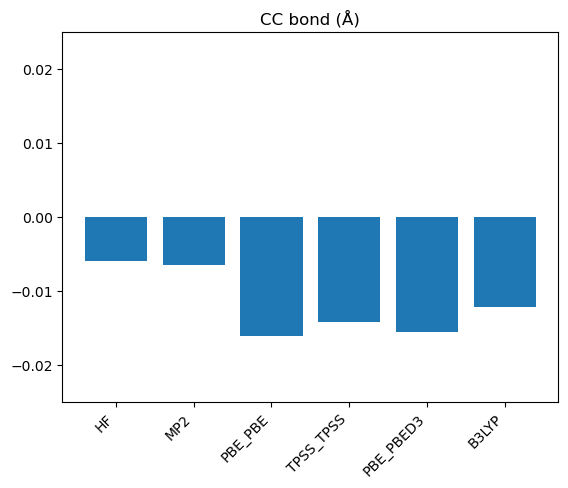

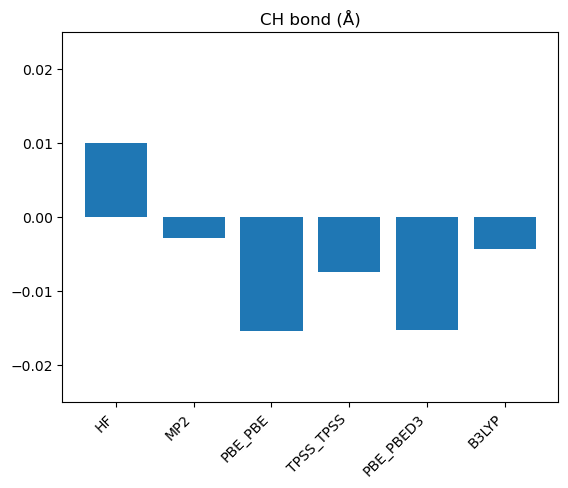

In [126]:
distance_names=["CC bond (Å)", "CH bond (Å)"]
exact_distances = [CC_exact, CH_exact]
job_names = job_dict.keys()

for index_indices, indices in enumerate([indices_CC, indices_CH]):
    distance_list = []
    for i, job_name in enumerate(job_dict.keys()):
        job_load = job_dict[job_name]
        structure = job_load.get_structure()
        distance = structure.get_distance(indices[0], indices[1])
        distance_exact = exact_distances[index_indices]
        error =  distance_exact - distance
        distance_list.append(error)
        #plt.text(i, error, job_name)

    plt.figure()
    plt.bar(range(len(distance_list)), distance_list)

    plt.xticks(range(len(job_names)), job_names, rotation=45, ha="right")
    plt.title(distance_names[index_indices])
    plt.ylim(-0.025, 0.025)
    plt.show()
    

### Plot of the angles

In [130]:
indices_HCC = [4, 2, 3]
indices_OCC = [0, 2, 3]
HCC_exact = 115.42
OCH_exact = 123.80

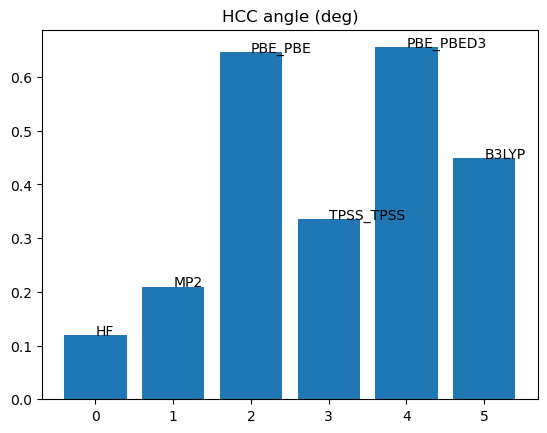

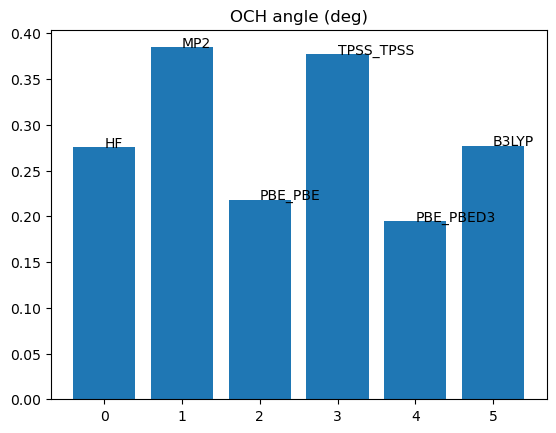

In [131]:
angle_names=["HCC angle (deg)", "OCH angle (deg)"]
exact_angles = [HCC_exact, OCH_exact]
for index_indices, indices in enumerate([indices_HCC, indices_OCH]):
    angle_list = []
    for i, job_name in enumerate(job_dict.keys()):
        job_load = job_dict[job_name]
        structure = job_load.get_structure()
        angle = structure.get_angle(indices[0], indices[1], indices[2])
        angle_exact = exact_angles[index_indices]
        error = angle_exact - angle
        angle_list.append(error)
        plt.text(i, error, job_name)

    plt.bar(range(len(angle_list)), angle_list)
    plt.title(angle_names[index_indices])
    plt.show()

## Exercise 5: Importance of long-range interactions for the benzene dimer

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Investigate the effect of including long-range interactions on the stability of different benzene dimer conformations
</div>

The benzene dimer has various stable conformations. Some of these conformers are shown in Figure 1 (found __[here](https://doi.org/10.1021/jp9034375)__). Initial structures for four different configurations of the dimers are provided.

<figure>
<img src="https://www.dropbox.com/s/tkjr2jbost0bhpf/dimers.png?raw=1">
</figure>

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Visualize the initial structures and think about the dominant interactions in these complexes. Compare with the previously studied biphenyl. How could could you model these interactions? </li>
<br>
<li> Which DFT-methods could be suitable to describe these systems? Choose one for each approach and do a single point calculation for the different configurations. Do you obtain what you expect? Use the 6-311+G* basis set and compare your results to a calculation using a DFT method that does not take these interactions into account. Also perform an optimization, what happens for the different LOTs?</li>
<br>
<li> Determine the interaction energy and compare with the data in Table 3 (found <a href="https://doi.org/10.1021/jp9034375">here</a>). </li>
</ol>
</div>

<figure>
<img src="https://www.dropbox.com/s/czjvda44a1wgtg6/table.png?raw=1">
</figure>

In [7]:
ex5 = pr.create_group('ex5')

In [8]:
# .xyz files are in session7_input (in the github, were found in supporting information).
S_configuration = ase_to_pyiron(read("session7_input/Sandwich_Benzene_Dimer.xyz"))
S_configuration.plot3d(spacefill=False)

NGLWidget()

In [9]:
T_configuration = ase_to_pyiron(read("session7_input/T_Shaped_Benzene_Dimer.xyz"))
T_configuration.plot3d(spacefill=False)

NGLWidget()

In [10]:
PD_configuration = ase_to_pyiron(read("session7_input/PD_Benzene_Dimer.xyz"))
PD_configuration.plot3d(spacefill=False)

NGLWidget()

In [36]:
n_atoms_molecule = 12
def BSSE_job(pr, name, jobtype, dimer, lot, basis_set, dispersion_correction = False, cluster = "shinx", cores = 1, run_time=10*60):
    job = pr.create_job(pr.job_type.Gaussian, name, delete_existing_job=True)
    
    ### Add the necessary variables to complete the definition of your job!
    job.structure = dimer
    job.input['jobtype'] = jobtype
    job.input['lot'] = lot
    job.input['basis_set'] = basis_set


    if dispersion_correction is not False:
        job.input['settings'] = {'Counterpoise':'2',
            'EmpiricalDispersion': dispersion_correction}

    else:
        job.input['settings'] = {'Counterpoise':'2'}
        
    job.input['bsse_idx'] = [0]*n_atoms_molecule + [1]*n_atoms_molecule
    job.server.queue = cluster
    job.server.cores = cores
    job.server.run_time = run_time

    job.run()
    return job

In [37]:
def get_name(jobtype, lot, dimer_name, dispersion):
    name_lot = lot.replace("-" , "_")
    name_dispersion = ""
    if dispersion is not False:
        name_job = "%s_%s_%s_%s" % (jobtype, dimer_name, name_lot, dispersion)
    else:
        name_job = "%s_%s_%s" % (jobtype, dimer_name, name_lot)
    return name_job

In [38]:
configurations_dict = {"S":S_configuration, "T": T_configuration, "PD": PD_configuration}
lot_base_dict = {"B3LYP":"B3LYP", "B3LYP-D3":"B3LYP", "PBEPBE":"PBEPBE", "PBEPBE-D3":"PBEPBE", "wB97XD":"wB97XD"}
dispersion_correction_dict =  {"B3LYP":False, "B3LYP-D3":"GD3", "PBEPBE":False, "PBEPBE-D3":"GD3", "wB97XD":False}
basis_set = "6-311+G*"

In [39]:
for configuration_name in configurations_dict.keys():
    for lot_name in lot_base_dict.keys():
        configuration = configurations_dict[configuration_name]
        lot = lot_base_dict[lot_name]
        dispersion = dispersion_correction_dict[lot_name]
        name_job = get_name("sp", lot, configuration_name, dispersion)
        print(name_job)
        job = BSSE_job(ex5, name_job, "sp", configuration, lot, basis_set, dispersion_correction=dispersion)

sp_S_B3LYP
The job sp_S_B3LYP was saved and received the ID: 1739
Queue system id:  294123160
sp_S_B3LYP_GD3
The job sp_S_B3LYP_GD3 was saved and received the ID: 1740
Queue system id:  294123170
sp_S_PBEPBE
The job sp_S_PBEPBE was saved and received the ID: 1741
Queue system id:  294123180
sp_S_PBEPBE_GD3
The job sp_S_PBEPBE_GD3 was saved and received the ID: 1742
Queue system id:  294123190
sp_S_wB97XD
The job sp_S_wB97XD was saved and received the ID: 1743
Queue system id:  294123200
sp_T_B3LYP
The job sp_T_B3LYP was saved and received the ID: 1744
Queue system id:  294123210
sp_T_B3LYP_GD3
The job sp_T_B3LYP_GD3 was saved and received the ID: 1745
Queue system id:  294123220
sp_T_PBEPBE
The job sp_T_PBEPBE was saved and received the ID: 1746
Queue system id:  294123230
sp_T_PBEPBE_GD3
The job sp_T_PBEPBE_GD3 was saved and received the ID: 1747
Queue system id:  294123240
sp_T_wB97XD
The job sp_T_wB97XD was saved and received the ID: 1748
Queue system id:  294123250
sp_PD_B3LYP
The 

In [40]:
ex5.job_table()

,id,status,chemicalformula,job,subjob,projectpath,project,timestart,timestop,totalcputime,computer,hamilton,hamversion,parentid,masterid
0,1650,finished,C12H12,opt_S_B3LYP_D3,/opt_S_B3LYP_D3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex5/,2026-01-02 18:19:29.801118,2026-01-02 18:21:02.896427,93.0,pyiron@node4009.donphan.os#4#shinx,Gaussian,0.1,None,None
1,1652,finished,C12H12,opt_S_PBEPBE_D3,/opt_S_PBEPBE_D3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex5/,2026-01-02 18:19:29.761661,2026-01-02 18:20:17.489982,47.0,pyiron@node4009.donphan.os#4#shinx,Gaussian,0.1,None,None
2,1655,finished,C12H12,opt_T_B3LYP_D3,/opt_T_B3LYP_D3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex5/,2026-01-02 18:19:30.020318,2026-01-02 18:21:24.543658,114.0,pyiron@node4009.donphan.os#4#shinx,Gaussian,0.1,None,None
3,1657,finished,C12H12,opt_T_PBEPBE_D3,/opt_T_PBEPBE_D3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex5/,2026-01-02 18:19:29.907306,2026-01-02 18:21:08.525545,98.0,pyiron@node4009.donphan.os#4#shinx,Gaussian,0.1,None,None
4,1660,finished,C12H12,opt_PD_B3LYP_D3,/opt_PD_B3LYP_D3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex5/,2026-01-02 18:19:35.286776,2026-01-02 18:26:23.054833,407.0,pyiron@node4009.donphan.os#4#shinx,Gaussian,0.1,None,None
5,1662,finished,C12H12,opt_PD_PBEPBE_D3,/opt_PD_PBEPBE_D3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex5/,2026-01-02 18:19:39.596736,2026-01-02 18:24:23.874963,284.0,pyiron@node4009.donphan.os#4#shinx,Gaussian,0.1,None,None
6,1678,finished,C12H12,sp_BSSE_S_B3LYP,/sp_BSSE_S_B3LYP,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex5/,2026-01-02 21:53:51.824480,2026-01-02 21:54:11.987830,20.0,pyiron@node4009.donphan.os#1#shinx,Gaussian,0.1,None,None
7,1679,finished,C12H12,sp_BSSE_S_B3LYP_GD3,/sp_BSSE_S_B3LYP_GD3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex5/,2026-01-02 21:53:54.467015,2026-01-02 21:54:23.165644,28.0,pyiron@node4009.donphan.os#1#shinx,Gaussian,0.1,None,None
8,1680,finished,C12H12,sp_BSSE_S_PBEPBE,/sp_BSSE_S_PBEPBE,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex5/,2026-01-02 21:53:54.449111,2026-01-02 21:54:18.132720,23.0,pyiron@node4009.donphan.os#1#shinx,Gaussian,0.1,None,None
9,1681,finished,C12H12,sp_BSSE_S_PBEPBE_GD3,/sp_BSSE_S_PBEPBE_GD3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session7/ex5/,2026-01-02 21:53:54.486492,2026-01-02 21:54:20.511115,26.0,pyiron@node4009.donphan.os#1#shinx,Gaussian,0.1,None,None


In [41]:
for lot_name in lot_base_dict.keys():
    energy_dict = {}
    for configuration_name in configurations_dict.keys():
        configuration = configurations_dict[configuration_name]
        lot = lot_base_dict[lot_name]
        dispersion = dispersion_correction_dict[lot_name]
        name_job = get_name("sp", lot, configuration_name, dispersion)
        job = ex5.load(name_job)
        bsse_df = job.bsse_to_pandas()
        interaction_energy_corrected = bsse_df["complexation_energy_corrected"][0]
        energy_dict[configuration_name] = interaction_energy_corrected * 23.060548867
    print("%s %.6f %.6f %.6f" % (lot_name, energy_dict["S"], energy_dict["T"], energy_dict["PD"]))
        

B3LYP 2.980000 0.590000 2.930000
B3LYP-D3 -1.120000 -2.790000 -2.270000
PBEPBE 1.570000 -0.440000 1.230000
PBEPBE-D3 -1.590000 -2.780000 -2.530000
wB97XD -1.890000 -3.030000 -3.280000
